# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

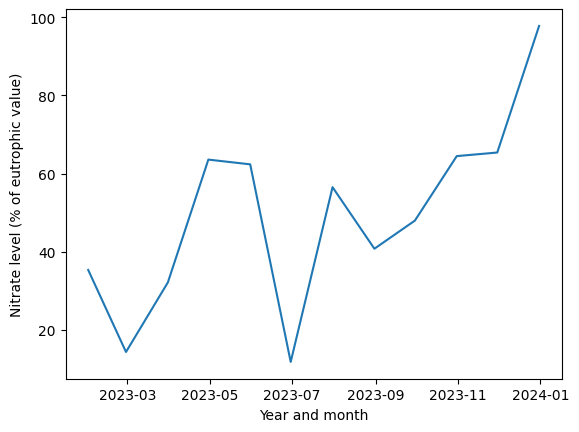

In [5]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

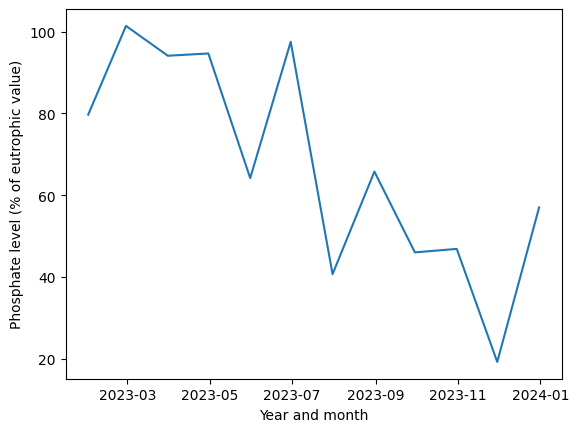

In [7]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

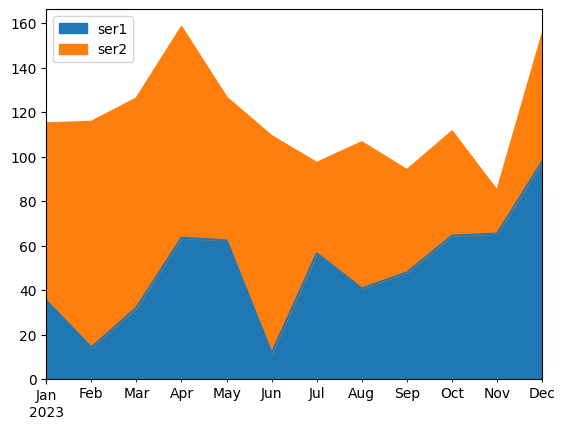

In [8]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

When looking at the area chart compared to the two line graphs, one advantage is you can see the two trends on the same chart. This allows us to see if there is any similar trends between the two. For example, we can see for both elements, they had a spike in April. However, a big disadvantage is that the y-axis isn't as understandable as it is in the two line charts. This is partially due to the lack of a y-axis label explaining what the numbers are representing. It is also important to note that the phosphate levels don't follow the same pattern as the line chart for the phosphate due to the stacked aspect of the chart. I would opt for the two line charts as we can compare them side by side and see if there is any noticeable correlations. I would also be sure to add x and y labels as well as a title to ensure the audience understands what the charts are representing.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

## Dataset 1: Instacart Data

For this dataset, I intially had to create a whole new model dataframe out of multiple csv files I was provided off of Kaggle. To do this, I had to use Google Colab as GitHub's file size limit was smaller than the size of one of the CSV files. To do this, I joined together files into the prior dataset and then created model features. Once I created the features, I joined them with the training dataset with a left join and filled NA values with 0. I then exported this model dataset and imported it into GitHub so I am able to perform my analysis here. 

In [14]:
import matplotlib.pyplot as plt

In [9]:
model_data = pd.read_csv('/workspaces/DX699---HW-Assignments/instacart.csv')

model_data.head()

,user_id,product_id,times_purchased,num_orders,frequency,Product Popularity,Last Product Order,Last Order,Orders Since Last Purchase,ordered
0,71,45,5,23,0.217391,0.005895,9,23,14,0.0
1,71,117,19,23,0.826087,0.001220,23,23,0,1.0
2,71,2078,1,23,0.043478,0.006499,3,23,20,0.0
3,71,2825,2,23,0.086957,0.003750,6,23,17,0.0
4,71,3376,2,23,0.086957,0.003609,19,23,4,1.0


<Axes: >

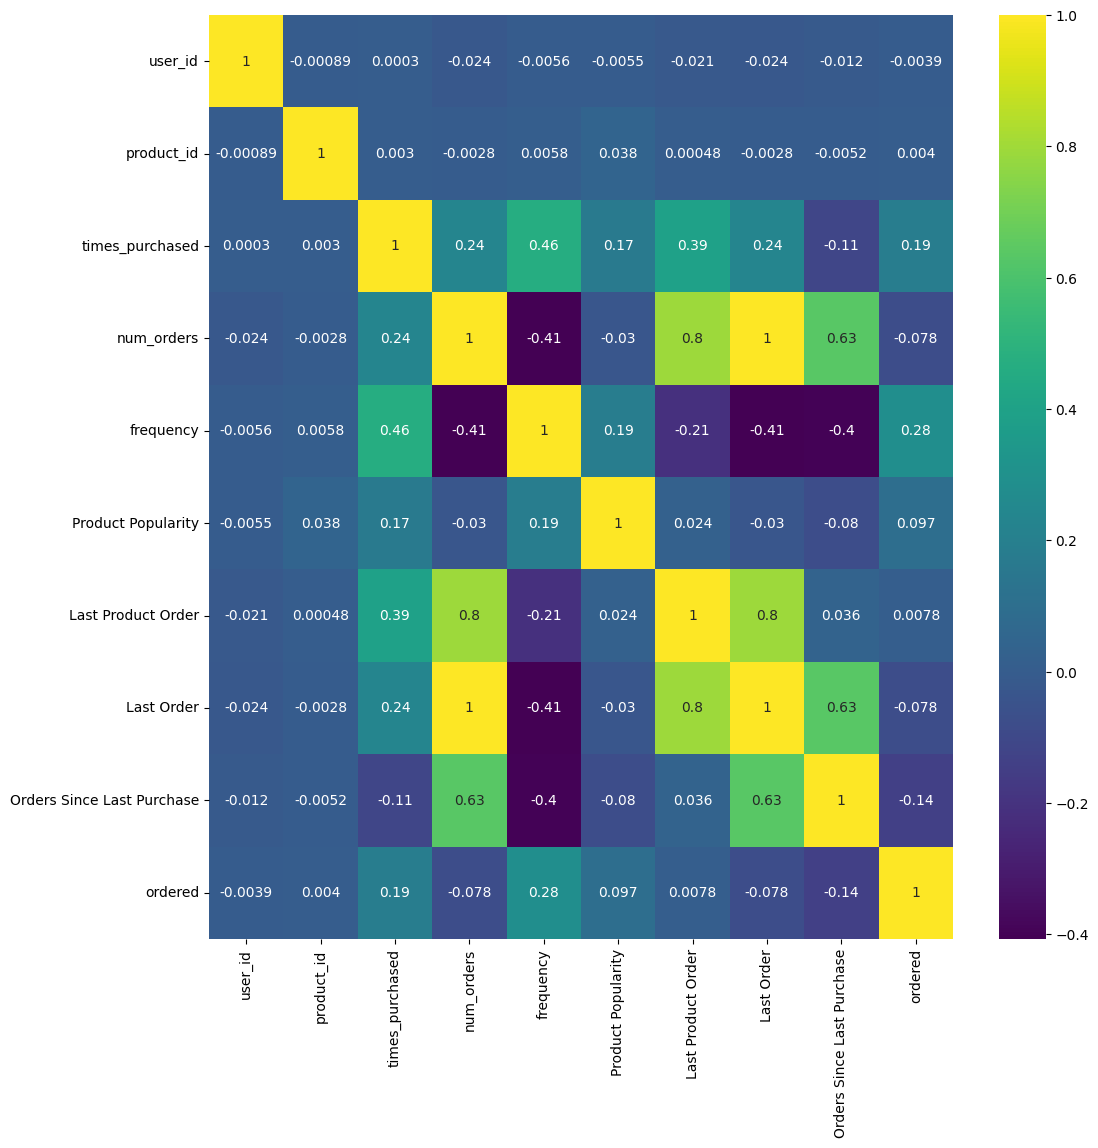

In [22]:
plt.figure(figsize = (12, 12))
sns.heatmap(model_data.corr(), annot = True, cmap = 'viridis')

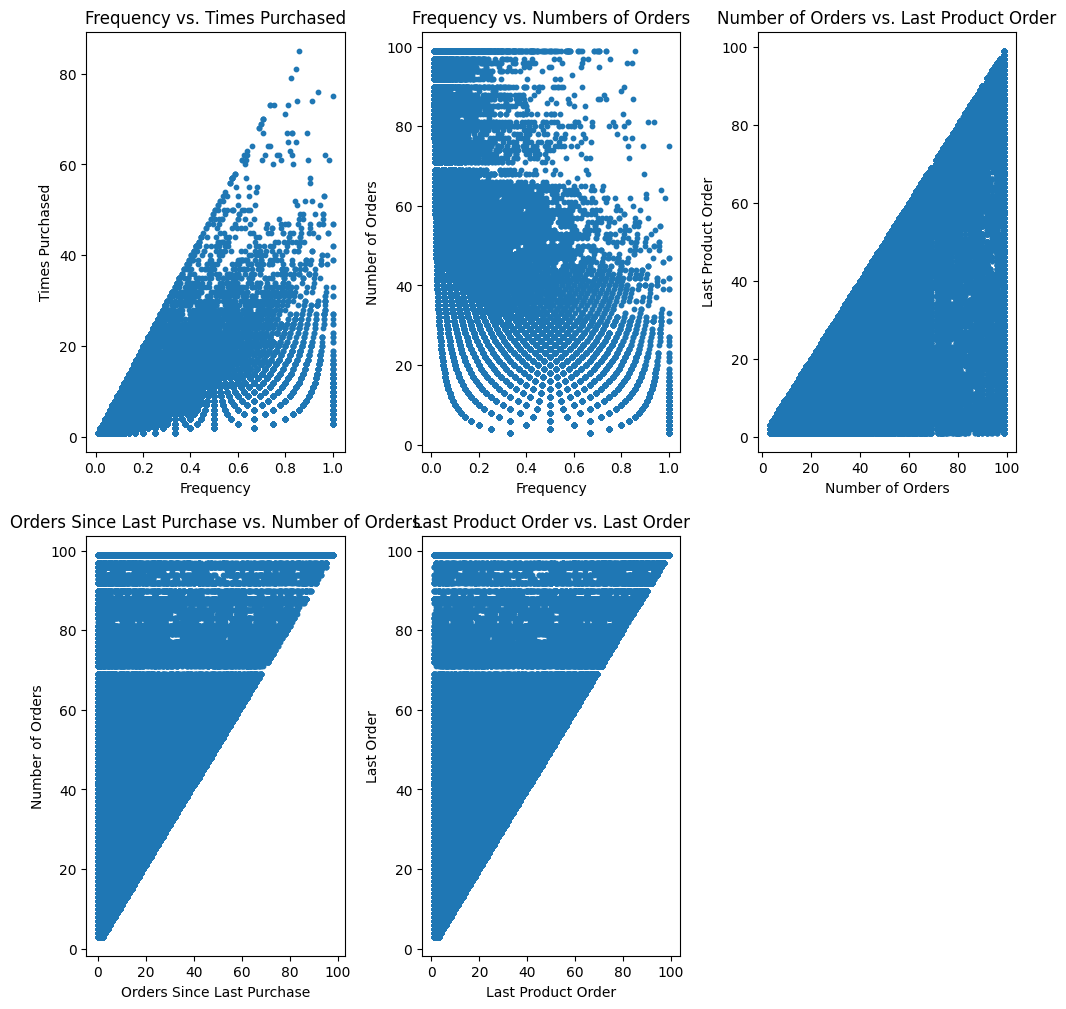

In [36]:
plt.figure(figsize = (12, 12))

plt.subplot(2, 3, 1)
plt.scatter(model_data['frequency'], model_data['times_purchased'], s = 10)
plt.xlabel('Frequency')
plt.ylabel('Times Purchased')
plt.title('Frequency vs. Times Purchased')

plt.subplot(2, 3, 2)
plt.scatter(model_data['frequency'], model_data['num_orders'], s = 10)
plt.xlabel('Frequency')
plt.ylabel('Number of Orders')
plt.title('Frequency vs. Numbers of Orders')

plt.subplot(2, 3, 3)
plt.scatter(model_data['num_orders'], model_data['Last Product Order'], s = 10)
plt.xlabel('Number of Orders')
plt.ylabel('Last Product Order')
plt.title('Number of Orders vs. Last Product Order')

plt.subplot(2, 3, 4)
plt.scatter(model_data['Orders Since Last Purchase'], model_data['num_orders'], s = 10)
plt.xlabel('Orders Since Last Purchase')
plt.ylabel('Number of Orders')
plt.title('Orders Since Last Purchase vs. Number of Orders')

plt.subplot(2, 3, 5)
plt.scatter(model_data['Last Product Order'], model_data['Last Order'], s = 10)
plt.xlabel('Last Product Order')
plt.ylabel('Last Order')
plt.title('Last Product Order vs. Last Order')

plt.subplots_adjust(wspace = 0.3)
plt.show()

I plotted the correlation matrix and then plotted the five highest correlations between variables. I am not surprised by a lot of these correlations since they are similar features, like last product order and last order. I also would expect the orders since last purchase to have a positive correlation with number of orders. 

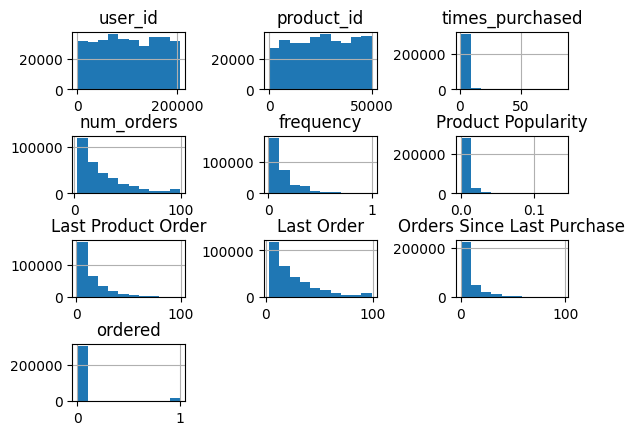

In [18]:
model_data.hist()
plt.subplots_adjust(wspace = 0.7, hspace = 0.8)
plt.show()

In [19]:
model_data['ordered'].value_counts()

ordered
0.0    302447
1.0     19992
Name: count, dtype: int64

In [ ]:
model_data.groupby('user_id').size()

np.float64(64.4878)

Looking at the histogram distributions I know that I will need to scale all of the values as they are all heavily skewed to the left. Furthermore, I notice that there are far more 0s for ordered instead of 1s. This class imbalance may lead to the model having some bias towards 0s when predicting, however, the class imbalance being large isn't too surprising. This is because often the user who is ordering has ordered over 50 items in there past and they aren't always going to order all of the items again. This would lead to there being more 0s, especially for users who have ordered over 100s of items in their past.

## Dataset 2: Amazon Reviews of Grocery and Food Items

This next dataset had the same issue as the instacart one of it being too large to upload to Github right away. To deal with this, I uploaded it into Google Colab and created a smaller subset to work with on Github.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.